# Image Captioning Bot

## Steps to be followed:-

#### Data collection
     
#### Understanding the data

#### Data Cleaning

#### Loading the training set

#### Data preprocessing: Images

#### Data preprocessing: Captions

#### Data Preparation using Generator Function

#### Word Embeddings

#### Model Architecture

#### Inference

#### Evaluation

# Modules Used:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
import re
from collections import Counter
import collections
import nltk
from nltk.corpus import stopwords
import string
import json
from time import time
import pickle
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from keras.models import Model, load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from keras.layers import Input, Dense, Dropout, Embedding, LSTM
from keras.layers import add

In [2]:
def readTextFile(path):
    with open(path) as f:
        captions = f.read()
        return captions
        

In [3]:
captions = readTextFile("./Dataset_image_cap_bot/Flickr_Data/Flickr_TextData/Flickr8k.token.txt")
captions = captions.split('\n')[:-1]

In [4]:
captions[0]

'1000268201_693b08cb0e.jpg#0\tA child in a pink dress is climbing up a set of stairs in an entry way .'

In [5]:
print(len(captions))

40460


In [6]:
first,second = captions[0].split('\t')
print(first.split("."))
print(second)

['1000268201_693b08cb0e', 'jpg#0']
A child in a pink dress is climbing up a set of stairs in an entry way .


# Dictionary to Map each Image with the List of captions

In [7]:
descriptions = {}

for x in captions:
    first,second = x.split('\t')
    img_name = first.split(".")[0]
    
    #if the image id is already present or not
    
    if descriptions.get(img_name) is None:
        descriptions[img_name] = []
        
    descriptions[img_name].append(second)
  

In [8]:
descriptions["1000268201_693b08cb0e"]

['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .']

# Reading the Image with OpenCV

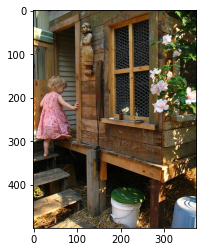

In [9]:
IMG_PATH = "./Dataset_image_cap_bot\Flickr_Data\Images/"

import cv2

import matplotlib.pyplot as plt

img = cv2.imread(IMG_PATH + "1000268201_693b08cb0e.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()





# Data Cleaning

In [10]:
def clean_text(sentence):
    sentence = sentence.lower()
    sentence = re.sub("[^a-z]+"," ",sentence)
    sentence = sentence.split()
    
    #Removing all the words having length of 1.
    sentence = [s for s in sentence if len(s)>1]
    sentence = " ".join(sentence)
    return sentence

In [11]:
clean_text("A cat is sitting over the house number 64")

'cat is sitting over the house number'

In [12]:
#Clean all Captions

for key,caption_list in descriptions.items():
    for i in range(len(caption_list)):
        caption_list[i] = clean_text(caption_list[i])

In [13]:
descriptions['1000268201_693b08cb0e']

['child in pink dress is climbing up set of stairs in an entry way',
 'girl going into wooden building',
 'little girl climbing into wooden playhouse',
 'little girl climbing the stairs to her playhouse',
 'little girl in pink dress going into wooden cabin']

In [14]:
# Write the data to text file
 
with open("descriptions_1.txt",'w') as f:
    f.write(str(descriptions))
   


# Creating Vocabulary

In [15]:
descriptions = None

with open("descriptions_1.txt",'r') as f:
    descriptions = f.read()
    
json_acceptable_string = descriptions.replace("'","\"")   
descriptions = json.loads(json_acceptable_string)


In [16]:
print(type(descriptions))

<class 'dict'>


In [17]:
# Vocab

vocab = set()
for key in descriptions.keys():
    [vocab.update(sentence.split()) for sentence in descriptions[key]]
    
print("Vocab Size : %d"%len(vocab))    

Vocab Size : 8424


In [18]:
#demo of above code:

vocabulary = set()
vocabulary.update(["hello"])
vocabulary.update(["hello"])
vocabulary.update(["hi"])
print(vocabulary)

{'hi', 'hello'}


In [19]:
#total no of words across all the sentences 

total_words = []

for key in descriptions.keys():
    [total_words.append(i) for des in descriptions[key] for i in des.split()]
    
print("Total Words %d"%len(total_words))    

Total Words 373837


In [20]:
# Filter Words from the Vocab according to certain threshfold frequency

counter = collections.Counter(total_words)
freq_cnt = dict(counter)
print(len(freq_cnt.keys()))

8424


In [21]:
# Sort this dictionary according to frequency count

sorted_freq_cnt = sorted(freq_cnt.items(),reverse=True,key=lambda x:x[1])

# Filter

threshold = 10
sorted_freq_cnt = [x for x in sorted_freq_cnt if x[1]>threshold]
total_words = [x[0] for x in sorted_freq_cnt]

In [22]:
len(total_words)

1845

# Prepairing Train/Test Data

In [23]:
train_file_data = readTextFile("./Dataset_image_cap_bot/Flickr_Data/Flickr_TextData/Flickr_8k.trainImages.txt")
test_file_data = readTextFile("./Dataset_image_cap_bot/Flickr_Data/Flickr_TextData/Flickr_8k.testImages.txt")

In [24]:
train = [row.split(".")[0] for row in train_file_data.split("\n")[:-1]]
test = [row.split(".")[0] for row in test_file_data.split("\n")[:-1]]


print(test[:10])

['3385593926_d3e9c21170', '2677656448_6b7e7702af', '311146855_0b65fdb169', '1258913059_07c613f7ff', '241347760_d44c8d3a01', '2654514044_a70a6e2c21', '2339106348_2df90aa6a9', '256085101_2c2617c5d0', '280706862_14c30d734a', '3072172967_630e9c69d0']


In [25]:
# Prepare Description for the Training Data

# Tweak - Add <s> start_token and <e> end_token to our training data.

train_descriptions = {}

for img_id in train:
    train_descriptions[img_id] = []
    for cap in descriptions[img_id]:
        cap_to_append = "startseq " + cap + " endseq"
        train_descriptions[img_id].append(cap_to_append)

In [26]:
train_descriptions["1000268201_693b08cb0e"]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq']

# Transfer Learning
  
 ### - Images ---> Features
 
 ### - Text ---> Features




# Step - 1 Image Feature Extraction

In [27]:
model = ResNet50(weights="imagenet", input_shape=(224,224,3))
model.summary

<bound method Model.summary of <keras.engine.functional.Functional object at 0x0000025899471760>>

In [28]:
#pretrained model layers

model.layers[-2].output

<KerasTensor: shape=(None, 2048) dtype=float32 (created by layer 'avg_pool')>

In [29]:
model_new = Model(model.input,model.layers[-2].output)

In [30]:
def preprocess_image(img):
    img = image.load_img(img, target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return img


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


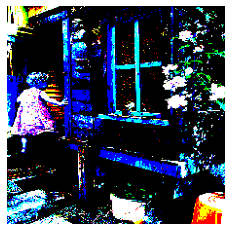

In [31]:
img = preprocess_image(IMG_PATH + "1000268201_693b08cb0e.jpg")

plt.imshow(img[0])
plt.axis("off")
plt.show()

In [32]:
def encode_image(img):
    img = preprocess_image(img)
    feature_vector = model_new.predict(img)
    feature_vector = feature_vector.reshape((-1,))
    print(feature_vector.shape)
    return feature_vector

In [33]:
encode_image(IMG_PATH + "1000268201_693b08cb0e.jpg")

1/1 [==============================] - 1s 1s/step
(2048,)


array([0.06535935, 0.16782571, 0.32517606, ..., 0.05107136, 0.32821193,
       1.0043372 ], dtype=float32)

In [34]:
from tqdm.notebook import tqdm

In [35]:
'''start = time()

from tqdm.notebook import tqdm

encoding_train = {}

for ix, img_id in tqdm(enumerate(train),total=len(train)):
     
    img = IMG_PATH+"/"+img_id+".jpg".format(train[ix])
    #encoding_train[img[len(image):]] = encode_image(img)
    encoding_train[img_id] = encode_image(img)
    if ix%100==0:
        print("Encoding image- "+ str(ix))
    
print("Time taken in seconds =", time()-start)'''

'start = time()\n\nfrom tqdm.notebook import tqdm\n\nencoding_train = {}\n\nfor ix, img_id in tqdm(enumerate(train),total=len(train)):\n     \n    img = IMG_PATH+"/"+img_id+".jpg".format(train[ix])\n    #encoding_train[img[len(image):]] = encode_image(img)\n    encoding_train[img_id] = encode_image(img)\n    if ix%100==0:\n        print("Encoding image- "+ str(ix))\n    \nprint("Time taken in seconds =", time()-start)'

# Storing encoded images to Disk

In [36]:
'''with open("./encoded_train_images.pkl", "wb") as encoded_pickle:
    pickle.dump(encoding_train, encoded_pickle)'''

'with open("./encoded_train_images.pkl", "wb") as encoded_pickle:\n    pickle.dump(encoding_train, encoded_pickle)'

In [37]:
start = time()

encoding_test = {}

for ix, img_id in tqdm(enumerate(test),total=len(test)):
            
    img = IMG_PATH+"/"+img_id+".jpg".format(test[ix])
    #encoding_test[img[len(image):]] = encode_image(img)
    encoding_test[img_id] = encode_image(img)
    
    if ix%100==0:
        print("Encoding image- "+ str(ix))
    
print("Time taken in seconds =", time()-start)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 140ms/step
(2048,)
Encoding image- 0
1/1 [==============================] - 0s 140ms/step
(2048,)
1/1 [==============================] - 0s 114ms/step
(2048,)
1/1 [==============================] - 0s 110ms/step
(2048,)
1/1 [==============================] - 0s 114ms/step
(2048,)
1/1 [==============================] - 0s 101ms/step
(2048,)
1/1 [==============================] - 0s 104ms/step
(2048,)
1/1 [==============================] - 0s 107ms/step
(2048,)
1/1 [==============================] - 0s 106ms/step
(2048,)
1/1 [==============================] - 0s 105ms/step
(2048,)
1/1 [==============================] - 0s 113ms/step
(2048,)
1/1 [==============================] - 0s 135ms/step
(2048,)
1/1 [==============================] - 0s 105ms/step
(2048,)
1/1 [==============================] - 0s 113ms/step
(2048,)
1/1 [==============================] - 0s 107ms/step
(2048,)
1/1 [==============================] - 0s 103ms/step
(2048,)
1/1 [=

1/1 [==============================] - 0s 106ms/step
(2048,)
1/1 [==============================] - 0s 106ms/step
(2048,)
1/1 [==============================] - 0s 115ms/step
(2048,)
1/1 [==============================] - 0s 103ms/step
(2048,)
1/1 [==============================] - 0s 110ms/step
(2048,)
1/1 [==============================] - 0s 103ms/step
(2048,)
1/1 [==============================] - 0s 106ms/step
(2048,)
1/1 [==============================] - 0s 106ms/step
(2048,)
1/1 [==============================] - 0s 110ms/step
(2048,)
1/1 [==============================] - 0s 106ms/step
(2048,)
1/1 [==============================] - 0s 103ms/step
(2048,)
1/1 [==============================] - 0s 108ms/step
(2048,)
1/1 [==============================] - 0s 106ms/step
(2048,)
1/1 [==============================] - 0s 104ms/step
(2048,)
1/1 [==============================] - 0s 102ms/step
(2048,)
1/1 [==============================] - 0s 108ms/step
(2048,)
1/1 [===================

1/1 [==============================] - 0s 106ms/step
(2048,)
1/1 [==============================] - 0s 105ms/step
(2048,)
1/1 [==============================] - 0s 103ms/step
(2048,)
1/1 [==============================] - 0s 110ms/step
(2048,)
1/1 [==============================] - 0s 105ms/step
(2048,)
1/1 [==============================] - 0s 103ms/step
(2048,)
1/1 [==============================] - 0s 106ms/step
(2048,)
1/1 [==============================] - 0s 102ms/step
(2048,)
1/1 [==============================] - 0s 106ms/step
(2048,)
1/1 [==============================] - 0s 104ms/step
(2048,)
1/1 [==============================] - 0s 111ms/step
(2048,)
1/1 [==============================] - 0s 111ms/step
(2048,)
1/1 [==============================] - 0s 105ms/step
(2048,)
1/1 [==============================] - 0s 105ms/step
(2048,)
1/1 [==============================] - 0s 107ms/step
(2048,)
1/1 [==============================] - 0s 108ms/step
(2048,)
1/1 [===================

1/1 [==============================] - 0s 128ms/step
(2048,)
1/1 [==============================] - 0s 114ms/step
(2048,)
1/1 [==============================] - 0s 130ms/step
(2048,)
1/1 [==============================] - 0s 150ms/step
(2048,)
1/1 [==============================] - 0s 128ms/step
(2048,)
1/1 [==============================] - 0s 111ms/step
(2048,)
1/1 [==============================] - 0s 116ms/step
(2048,)
1/1 [==============================] - 0s 108ms/step
(2048,)
1/1 [==============================] - 0s 133ms/step
(2048,)
1/1 [==============================] - 0s 105ms/step
(2048,)
1/1 [==============================] - 0s 105ms/step
(2048,)
1/1 [==============================] - 0s 102ms/step
(2048,)
1/1 [==============================] - 0s 112ms/step
(2048,)
1/1 [==============================] - 0s 115ms/step
(2048,)
1/1 [==============================] - 0s 104ms/step
(2048,)
1/1 [==============================] - 0s 107ms/step
(2048,)
1/1 [===================

1/1 [==============================] - 0s 117ms/step
(2048,)
1/1 [==============================] - 0s 123ms/step
(2048,)
1/1 [==============================] - 0s 119ms/step
(2048,)
1/1 [==============================] - 0s 121ms/step
(2048,)
1/1 [==============================] - 0s 108ms/step
(2048,)
1/1 [==============================] - 0s 110ms/step
(2048,)
1/1 [==============================] - 0s 113ms/step
(2048,)
1/1 [==============================] - 0s 109ms/step
(2048,)
1/1 [==============================] - 0s 107ms/step
(2048,)
1/1 [==============================] - 0s 117ms/step
(2048,)
1/1 [==============================] - 0s 106ms/step
(2048,)
1/1 [==============================] - 0s 108ms/step
(2048,)
1/1 [==============================] - 0s 114ms/step
(2048,)
1/1 [==============================] - 0s 105ms/step
(2048,)
1/1 [==============================] - 0s 103ms/step
(2048,)
1/1 [==============================] - 0s 108ms/step
(2048,)
1/1 [===================

1/1 [==============================] - 0s 106ms/step
(2048,)
1/1 [==============================] - 0s 111ms/step
(2048,)
1/1 [==============================] - 0s 105ms/step
(2048,)
1/1 [==============================] - 0s 103ms/step
(2048,)
1/1 [==============================] - 0s 112ms/step
(2048,)
1/1 [==============================] - 0s 108ms/step
(2048,)
1/1 [==============================] - 0s 111ms/step
(2048,)
1/1 [==============================] - 0s 111ms/step
(2048,)
1/1 [==============================] - 0s 114ms/step
(2048,)
1/1 [==============================] - 0s 111ms/step
(2048,)
1/1 [==============================] - 0s 108ms/step
(2048,)
1/1 [==============================] - 0s 104ms/step
(2048,)
1/1 [==============================] - 0s 145ms/step
(2048,)
1/1 [==============================] - 0s 113ms/step
(2048,)
1/1 [==============================] - 0s 116ms/step
(2048,)
1/1 [==============================] - 0s 115ms/step
(2048,)
1/1 [===================

In [38]:
#Save the bottleneck train features to disk

''''with open("./encoded_test_images.pkl", "wb") as encoded_pickle:
    pickle.dump(encoding_test, encoded_pickle)

SyntaxError: EOF while scanning triple-quoted string literal (Temp/ipykernel_18056/695755032.py, line 4)

In [39]:
# Load the train images features from disk

with open("./encoded_train_images.pkl", "rb") as encoded_pickle:
     encoding_train = pickle.load(encoded_pickle)

# Data pre-processing for Captions

In [40]:
len(total_words)

1845

In [41]:
"""
word_to_idx is mapping between each unique word in all_vocab to int value 
and idx_to_word is vice-versa
"""



word_to_idx = {}
idx_to_word = {}

for i,word in enumerate(total_words):
    word_to_idx[word] = i+1
    idx_to_word[i+1] = word
   

In [42]:
word_to_idx["dog"]

6

In [43]:
idx_to_word[6]

'dog'

In [44]:
print(len(idx_to_word))

1845


In [45]:
#  need to add these startseq and endseq to dictionary

word_to_idx['startseq'] = 1846
word_to_idx['endseq'] = 1847

idx_to_word[1846] = 'startseq'
idx_to_word[1847] = 'endseq'

In [46]:
#  vocab_size is total vocabulary len +1 because we will append 0's as well. 

vocab_size = len(idx_to_word)+1
print(vocab_size)

1848


In [47]:
all_captions_len = []

for key in train_descriptions.keys():
    for cap in train_descriptions[key]:
        all_captions_len.append(len(cap.split()))

max_len = max(all_captions_len)
print(max_len)

35


# Data Loader(Generator)

In [48]:
def data_generator(train_descriptions, encoding_train, word_to_idx, max_len, num_photos_per_batch):

    X1, X2, y = [], [], []

    n=0

    while True:
        
        for key, desc_list in train_descriptions.items():
            n +=1
          
            photo = encoding_train[key]

            for desc in desc_list:
                
                seq = [ word_to_idx[word] for word in desc.split() if word in word_to_idx]  

                for i in range(1,len(seq)):

                    in_seq = seq[0:i]
                    out_seq = seq[i]

                    in_seq = pad_sequences([in_seq], maxlen=max_len, value=0, padding='post')[0]

                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    X1.append(photo)
                    X2.append(in_seq)
                    y.append(out_seq)

            if n==num_photos_per_batch:
                yield [np.array(X1), np.array(X2)], np.array(y)
                X1, X2, y = [], [], []
                n=0

# Word Embedding

In [49]:
f = open("./glove.6B.50d.txt", encoding = 'utf8')

In [50]:
embedding_index = {}

for line in f:
    values = line.split()
    
    word = values[0]
    word_embedding = np.array(values[1:],dtype='float')
    embedding_index[word] = word_embedding
    


In [51]:
f.close()

In [52]:
embedding_index['apple']

array([ 0.52042 , -0.8314  ,  0.49961 ,  1.2893  ,  0.1151  ,  0.057521,
       -1.3753  , -0.97313 ,  0.18346 ,  0.47672 , -0.15112 ,  0.35532 ,
        0.25912 , -0.77857 ,  0.52181 ,  0.47695 , -1.4251  ,  0.858   ,
        0.59821 , -1.0903  ,  0.33574 , -0.60891 ,  0.41742 ,  0.21569 ,
       -0.07417 , -0.5822  , -0.4502  ,  0.17253 ,  0.16448 , -0.38413 ,
        2.3283  , -0.66682 , -0.58181 ,  0.74389 ,  0.095015, -0.47865 ,
       -0.84591 ,  0.38704 ,  0.23693 , -1.5523  ,  0.64802 , -0.16521 ,
       -1.4719  , -0.16224 ,  0.79857 ,  0.97391 ,  0.40027 , -0.21912 ,
       -0.30938 ,  0.26581 ])

# Converting words into vectors Directly-(Embedding Layer Output) 

In [52]:
def get_embedding_matrix():
    
    emb_dim = 50
    matrix = np.zeros((vocab_size,emb_dim))
    
    for word, idx in word_to_idx.items():
        embedding_vector = embedding_index.get(word)
        
        if embedding_vector is not None:
            matrix[idx] = embedding_vector
            
    return matrix


embedding_matrix = get_embedding_matrix()

In [56]:
embedding_matrix.shape

(1848, 50)

In [57]:
#embedding_matrix[1847]

# Model Architecture

In [58]:
# image feature extractor model

input_img_features = Input(shape=(2048,))
inp_img1 = Dropout(0.3)(input_img_features)
inp_img2 = Dense(256, activation='relu')(inp_img1)


In [59]:
# partial caption sequence model

input_captions = Input(shape = (max_len,))
inp_cap1 = Embedding(input_dim = vocab_size, output_dim=50, mask_zero=True)(input_captions)
inp_cap2 = Dropout(0.3)(inp_cap1)
inp_cap3 = LSTM(256)(inp_cap2)

In [60]:
decoder1 = add([inp_img2 , inp_cap3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

# Merge 2 networks
model = Model(inputs=[input_img_features, input_captions], outputs=outputs)

In [61]:
model.summary() # Basicallly Show how my Layers are connected

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 35)]         0           []                               
                                                                                                  
 input_3 (InputLayer)           [(None, 2048)]       0           []                               
                                                                                                  
 embedding (Embedding)          (None, 35, 50)       92400       ['input_4[0][0]']                
                                                                                                  
 dropout_1 (Dropout)            (None, 2048)         0           ['input_3[0][0]']                
                                                                                            

In [62]:
model.layers[2].set_weights([embedding_matrix])
model.layers[2].trainable = False

In [63]:
model.compile(loss="categorical_crossentropy", optimizer="adam")

# Training of Model

In [64]:
#epochs = 15
#number_pics_per_batch = 3
#steps = len(train_descriptions)//number_pics_per_batch

In [65]:
#for i in range(epochs):
   # generator = data_generator(train_descriptions, encoding_train, word_to_idx, max_len, number_pics_per_batch)
   # model.fit_generator(generator, epochs=1, steps_per_epoch=steps, verbose=1)
   # model.save('./model_weights/model_' + str(i) + '.h5')

In [66]:
model = load_model('./model_weights/model_9.h5')

# Predictions

In [67]:
def predict_caption(photo):
    in_text = "startseq"
    
    for i in range(max_len):
        sequence = [word_to_idx[w] for w in in_text.split() if w in word_to_idx]
        sequence = pad_sequences([sequence], maxlen=max_len, padding='post')

        ypred =  model.predict([photo,sequence])
        ypred = ypred.argmax()
        word = idx_to_word[ypred]
        in_text+= ' ' +word
        
        if word =='endseq':
            break
        
        
    final_caption =  in_text.split()
    final_caption = final_caption[1:-1]
    final_caption = ' '.join(final_caption)
    
    return final_caption

1/1 [==============================] - 0s 31ms/step
man in black shirt and jeans is sitting on bench with his arms around his head


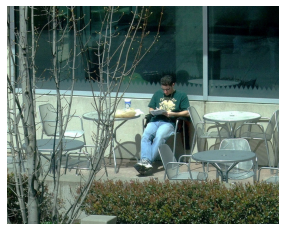

1/1 [==============================] - 0s 17ms/step
man and woman are standing in front of crowd


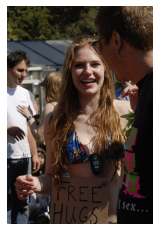

1/1 [==============================] - 0s 24ms/step
boy in blue shirt and blue shorts is sitting on bench with his arms crossed


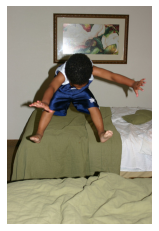

1/1 [==============================] - 0s 24ms/step
man in red shirt and black shorts is skating on the street


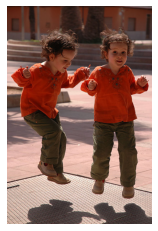

1/1 [==============================] - 0s 16ms/step
two people are sitting on the edge of cliff overlooking the ocean


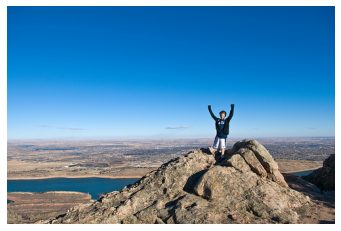

1/1 [==============================] - 0s 8ms/step
man with glasses and black jacket is standing in front of building


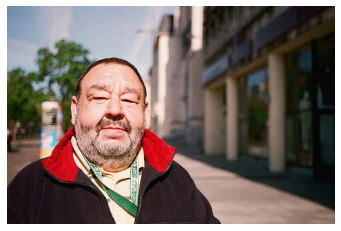

1/1 [==============================] - 0s 16ms/step
man in black shorts is jumping into the air


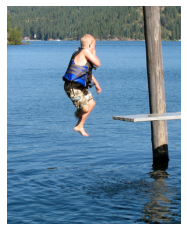

1/1 [==============================] - 0s 24ms/step
two people are sitting on the beach


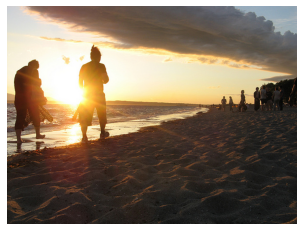

1/1 [==============================] - 0s 16ms/step
group of people are sitting in the direction direction


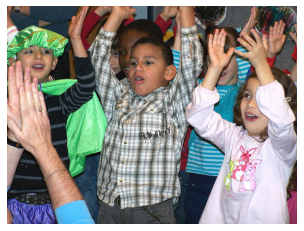

1/1 [==============================] - 0s 16ms/step
man and woman are sitting on the edge of the ocean


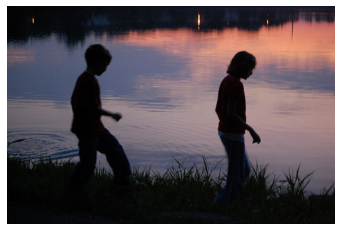

1/1 [==============================] - 0s 26ms/step
boy in green shirt is jumping on the edge of the water


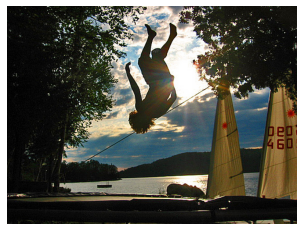

1/1 [==============================] - 0s 24ms/step
dog jumps over barrier


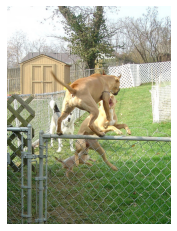

1/1 [==============================] - 0s 24ms/step
the man is wearing black shirt and holding the


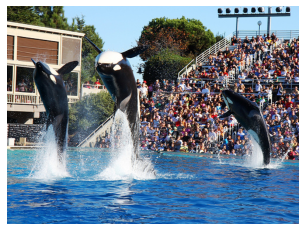

1/1 [==============================] - 0s 24ms/step
dog jumps over hurdle


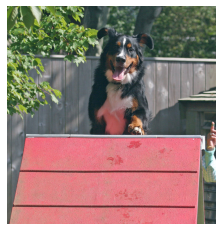

1/1 [==============================] - 0s 16ms/step
the man is sitting on the edge of the ocean


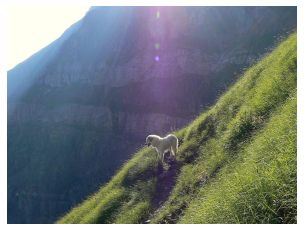

In [68]:
# pick some random Images and see results
for i in range(15):
    idx = np.random.randint(0,1000)
    all_img_names = list(encoding_test.keys())
    img_name = all_img_names[idx]
    photo_2048 = encoding_test[img_name].reshape((1,2048))
    
    i = plt.imread(IMG_PATH+img_name+".jpg")
    caption = predict_caption(photo_2048)
    print(caption)
    plt.imshow(i)
    plt.axis("off")
    plt.show()

In [69]:
encoding_test['3385593926_d3e9c21170'].shape

(2048,)

In [70]:
new_path = "C:/Users/PC-BHAVYA/Downloads/pikrepo.jpg"

In [71]:
a = encode_image(new_path)
b = a.reshape(1,2048)
c = plt.imread(new_path)
d = predict_caption(b)



1/1 [==============================] - 0s 266ms/step
(2048,)
1/1 [==============================] - 0s 31ms/step


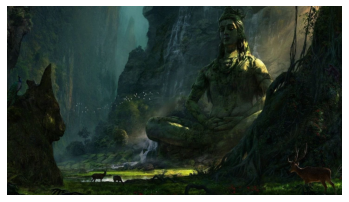

man is sitting on rock stump into the water


In [72]:
plt.imshow(c)
plt.axis("off")
plt.show()
print(d)
